CREDIT CARD FRAUD DETECTION USING ANN 


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv("creditcard.csv")

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.columns


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
261256,159932.0,-1.260852,0.953186,0.227751,-0.662564,-0.341343,0.986242,-0.604827,1.192114,0.391616,...,0.535339,1.435895,0.119593,-0.982251,-1.150428,0.540921,-0.382584,0.056636,25.90,0
272939,165342.0,2.080934,-1.598664,0.286959,-0.783258,-1.266704,1.735420,-2.174632,0.556663,1.283495,...,0.278918,1.271109,-0.004543,-0.242089,-0.074694,0.030984,0.090764,-0.043735,15.60,0
179182,123959.0,0.101526,0.683424,0.563786,-0.614788,0.479858,-0.030530,0.656622,-0.126637,0.090852,...,-0.236048,-0.525403,0.168305,0.663223,-0.857378,-0.053982,-0.261882,-0.197871,37.00,0
109070,71199.0,-1.166005,1.479815,0.154290,1.011933,-0.315828,0.348479,0.488454,0.804401,-1.100661,...,-0.295715,-1.155911,0.280664,-0.842133,-0.482073,-0.689737,-0.152990,-0.048253,110.44,0
236085,148664.0,-0.388313,0.969079,0.461054,-1.294712,1.089623,-0.522115,1.223895,-0.125373,-0.676752,...,0.379878,1.107738,-0.419110,0.819028,0.287261,-0.284595,0.100693,0.135495,3.00,0
40426,40230.0,-1.128515,1.409735,1.145939,-0.228153,0.225979,-0.331095,0.593449,0.548174,-1.251507,...,-0.265825,-0.887977,-0.067734,-0.010261,0.178131,0.080355,0.116485,0.039897,4.53,0
255938,157469.0,2.041517,0.287473,-1.453664,0.523030,0.303231,-1.139899,0.300701,-0.357547,0.223822,...,-0.313397,-0.722132,0.385719,1.094533,-0.274134,0.134560,-0.051713,-0.022040,0.89,0
172954,121305.0,-0.417634,-0.084307,0.667477,-1.969298,-0.158038,0.344142,0.369621,0.139875,0.944027,...,0.253129,0.800058,-0.192263,-1.037995,-0.623190,0.686084,0.035335,0.170787,102.00,0
162371,115050.0,-0.260063,1.302837,-0.747246,0.763303,1.776130,-0.006743,1.755409,-0.398896,-0.260853,...,-0.105524,0.324014,-0.366508,0.067050,0.035390,-0.444140,0.230328,-0.113172,49.06,0
108683,71022.0,-1.173255,1.293135,0.089735,-1.109802,-0.877736,-1.592091,0.149899,0.183000,-1.585408,...,0.004044,-0.408989,0.160497,0.587471,-0.586790,-0.704904,-0.814166,-0.175687,23.94,0


In [10]:
df.shape

(284807, 31)

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

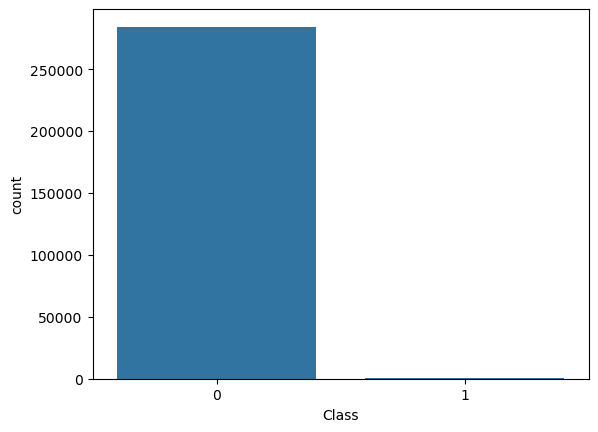

In [13]:
sns.countplot(x='Class',data=df)
plt.show()

<Axes: >

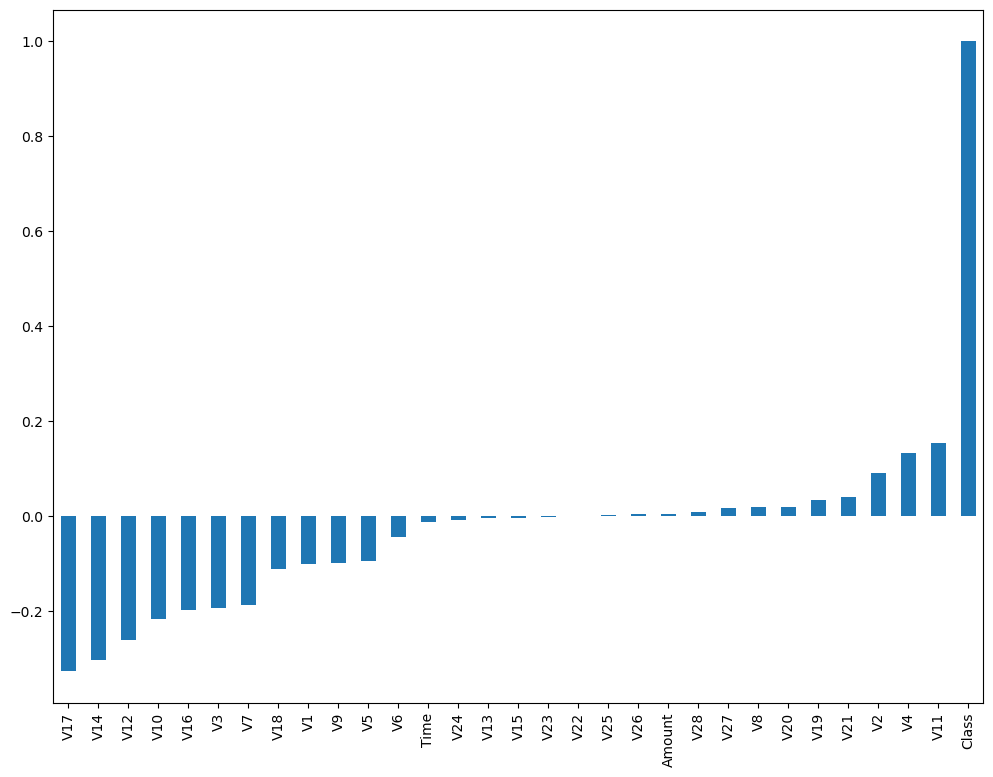

In [14]:
plt.figure(figsize=(12,9))
df.corr()['Class'].sort_values().plot(kind='bar')

In [15]:
#class is target column
X=df.drop("Class",axis=1)
y=df["Class"]

In [16]:
#TRAIN_TEST_SPLIT
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=30)

In [17]:
X_train.shape,X_test.shape

((227845, 30), (56962, 30))

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [19]:
#fit only on trainging data
X_train=scaler.fit_transform(X_train)

In [20]:
#TRANSFORM TEST DATA
X_test=scaler.transform(X_test)

In [21]:
X_train_df=pd.DataFrame(X_train)
X_train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-0.640838,0.597290,0.336298,-0.334559,0.788037,0.297914,-0.210366,0.052867,0.091365,-0.186593,...,-0.206391,-0.026845,-0.035095,-0.213938,-0.767252,1.154573,-0.604570,0.102272,0.114467,-0.344215
1,1.252673,0.027813,0.547485,-0.683529,-0.051838,0.084665,-0.761993,0.489354,0.244078,-0.319981,...,-0.211766,0.570023,1.439005,0.071613,-0.124738,-0.622618,-0.349604,-0.226055,-0.164172,-0.101361
2,1.485602,-0.583308,-0.005360,1.098985,0.237701,0.837369,-0.501754,0.284505,0.085365,0.229576,...,0.030548,-0.533279,-1.632325,0.225422,-0.311618,-0.146546,-2.467694,0.310943,0.491543,-0.267749
3,-0.859056,0.748107,-0.475729,-0.011261,-0.982195,-0.667990,-0.614358,-0.369840,-0.259541,-2.135544,...,-0.348173,-0.626093,-1.281185,0.242943,0.067587,0.564252,-0.880287,0.055797,0.049954,-0.225024
4,-1.068328,-0.176298,0.662117,0.844430,0.047940,-0.016809,-0.732804,0.570592,-0.048085,-0.315647,...,0.131165,-0.363629,-0.990461,0.001969,0.534609,-0.326028,0.152344,0.593037,0.291723,-0.314162


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer,Dropout

In [23]:
# Creating the model
model1 = Sequential()
model1.add(InputLayer(input_shape=(30,)))  # Input layer with 26 input features
model1.add(Dense(26, activation='relu'))  # First hidden layer
model1.add(Dense(15, activation='relu'))  # Second hidden layer
model1.add(Dense(1, activation='sigmoid'))  # Output layer
model1.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 26)             │           806 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           405 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,227 (4.79 KB)

 Trainable params: 1,227 (4.79 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model1.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [25]:
model1.fit(X_train,y_train,epochs=20,batch_size=10,validation_split=0.2)

Epoch 1/20
18228/18228 ━━━━━━━━━━━━━━━━━━━━ 79s 4ms/step - accuracy: 0.9985 - loss: 0.0070 - val_accuracy: 0.9991 - val_loss: 0.0044
Epoch 2/20
18228/18228 ━━━━━━━━━━━━━━━━━━━━ 69s 4ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9992 - val_loss: 0.0042
Epoch 3/20
18228/18228 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9993 - val_loss: 0.0038
Epoch 4/20
18228/18228 ━━━━━━━━━━━━━━━━━━━━ 70s 4ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9992 - val_loss: 0.0039
Epoch 5/20
18228/18228 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9992 - val_loss: 0.0041
Epoch 6/20
18228/18228 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9993 - val_loss: 0.0048
Epoch 7/20
18228/18228 ━━━━━━━━━━━━━━━━━━━━ 70s 4ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9992 - val_loss: 0.0041
Epoch 8/20
18228/18228 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 

In [26]:
model_loss = pd.DataFrame(model1.history.history)

<Axes: >

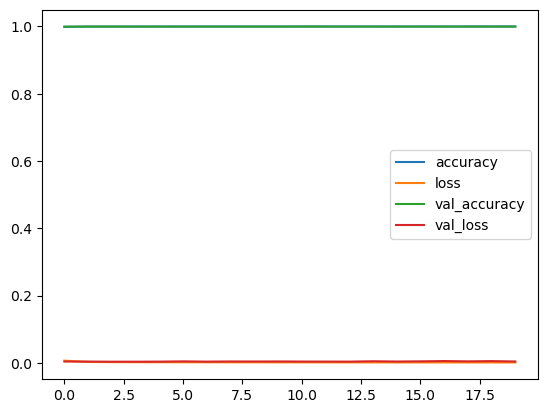

In [27]:
model_loss.plot()

In [28]:
# Early Stopping

model = Sequential()
model.add(InputLayer(input_shape=(30,)))  # Input layer with 26 input features
model.add(Dense(units=26,activation='relu'))
model.add(Dense(units=15,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
early_stop=EarlyStopping(monitor='val_loss',mode='min',patience=50)

In [30]:
model.fit(x=X_train,
          y=y_train,
          epochs=10,
          validation_data=(X_test, y_test),
          callbacks=[early_stop]
          )

Epoch 1/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - accuracy: 0.9989 - loss: 0.0078 - val_accuracy: 0.9994 - val_loss: 0.0043
Epoch 2/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 49s 7ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9994 - val_loss: 0.0038
Epoch 3/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 84s 7ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9994 - val_loss: 0.0041
Epoch 4/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9992 - val_loss: 0.0044
Epoch 5/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 83s 7ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9995 - val_loss: 0.0037
Epoch 6/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9994 - val_loss: 0.0039
Epoch 7/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9994 - val_loss: 0.0043
Epoch 8/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.9995 - loss: 0

In [35]:
loss,accuracy=model.evaluate(X_test,y_test)
print("Test Loss",loss)
print("Test Accuracy",accuracy)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9994 - loss: 0.0044
Test Loss 0.004372786730527878
Test Accuracy 0.9994031190872192


In [36]:
model_loss = pd.DataFrame(model.history.history)
print(model_loss)

   accuracy      loss  val_accuracy  val_loss
0  0.998885  0.007837      0.999403  0.004326
1  0.999403  0.002900      0.999438  0.003773
2  0.999425  0.002571      0.999421  0.004149
3  0.999456  0.002294      0.999245  0.004407
4  0.999487  0.002217      0.999473  0.003705
5  0.999539  0.002041      0.999386  0.003866
6  0.999548  0.001928      0.999403  0.004324
7  0.999530  0.001976      0.999456  0.004005
8  0.999565  0.001764      0.999438  0.004091
9  0.999561  0.001779      0.999403  0.004373


<Axes: >

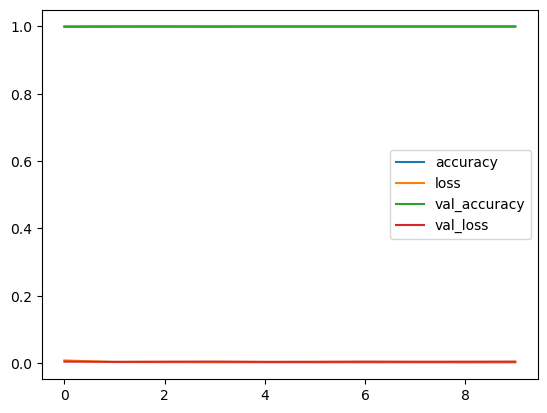

In [37]:
model_loss.plot()

In [38]:
from tensorflow.keras.layers import Dropout

In [39]:
model = Sequential()
model.add(InputLayer(input_shape=(30,)))  # Explicitly adding input layer with 26 input features
model.add(Dense(26,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(15,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [40]:
model.fit(x=X_train,
          y=y_train,
          epochs=10,
          validation_data=(X_test, y_test),
          callbacks=[early_stop]
          )

Epoch 1/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - accuracy: 0.9963 - loss: 0.0211 - val_accuracy: 0.9989 - val_loss: 0.0069
Epoch 2/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 79s 7ms/step - accuracy: 0.9988 - loss: 0.0058 - val_accuracy: 0.9992 - val_loss: 0.0060
Epoch 3/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 85s 7ms/step - accuracy: 0.9989 - loss: 0.0057 - val_accuracy: 0.9993 - val_loss: 0.0058
Epoch 4/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - accuracy: 0.9989 - loss: 0.0051 - val_accuracy: 0.9993 - val_loss: 0.0062
Epoch 5/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 76s 7ms/step - accuracy: 0.9989 - loss: 0.0053 - val_accuracy: 0.9990 - val_loss: 0.0050
Epoch 6/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 48s 7ms/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.9992 - val_loss: 0.0057
Epoch 7/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - accuracy: 0.9990 - loss: 0.0046 - val_accuracy: 0.9992 - val_loss: 0.0049
Epoch 8/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 74s 6ms/step - accuracy: 0.9989 - loss: 0

In [41]:
loss,accuracy=model.evaluate(X_test,y_test)
print("Test Loss",loss)
print("Test Accuracy",accuracy)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9994 - loss: 0.0043
Test Loss 0.004294029902666807
Test Accuracy 0.9994031190872192


In [42]:
y_pred=model.predict(X_test) # making predictions
print(y_pred)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
[[1.6762958e-04]
 [3.5766118e-07]
 [7.9595178e-01]
 ...
 [2.3450940e-07]
 [5.8704412e-05]
 [3.1756790e-05]]


In [43]:
#convert probabilities to 0 or 1
y_pred=(y_pred>0.5)
print(y_pred)

[[False]
 [False]
 [ True]
 ...
 [False]
 [False]
 [False]]


In [44]:
#confusion matrix
from sklearn.metrics import confusion_matrix

In [45]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[56841     9]
 [   25    87]]


In [46]:
#classification report 
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56850
           1       0.91      0.78      0.84       112

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [47]:
#accuracy score
from sklearn.metrics import accuracy_score
print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 0.999403110845827


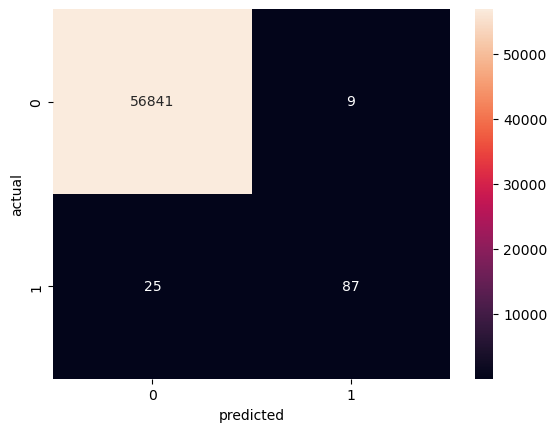

In [48]:
#VISUALIZATION
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

In [54]:

input_data = X_test[0].reshape(1, -1)

prediction = model.predict(input_data)

if prediction[0] == 0:
    print("The transaction is Not Fraud")
else:
    print("The transaction is Fraud")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
The transaction is Fraud


In [55]:
model.save("fraud_detection_project.h5")
print("model saved successfully")

model saved successfully


In [2]:
import os
os.getcwd()

'C:\\Users\\DELL\\Documents\\SAP_PROJECT'